# Scenario 1 — 170 km / 93 GBaud (OFC/CLEO): reproduce Fig. 1b

Full performance-vs-complexity figure: received SNR (peak over power) vs
complexity [RM/2D] for **EDC, Ideal DBP, OSSFM, LDBP, ESSFM, L-ESSFM**, at the
two oversamplings **n=1.125 (solid)** and **n=2 (dashed)**.

Models are loaded from `results/<scenario>/` (trained for this scenario).
The simulation runs on the shared forward.

NOTE: evaluating all curves loads the 2 GB forward and runs many backprops; in a
notebook it's fine cell-by-cell. Each method is computed independently below.

In [1]:
import sys, os
_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system
from backprop import curve
from complexity import eval_compl, complexity_ldbp

SCENARIO = 'scenario_170km_93GBd'
RESDIR   = f'results/{SCENARIO}'
L_KM, R_GBD = 170e3, 93e9
CFG  = {1.125: f'config/{SCENARIO}.ini', 2.0: 'config/_test_n2.ini'}
NS_FULL = [1,2,3,4,5,6,7,8,9,10,20,30,40,50]   # n=1.125
NS_RED  = [1,5,10,20,30,40,50]                  # n=2 (reduced)


## 1. Load the shared forward

In [2]:
fwd = np.load('/home/dario/ldbp2/forward_resultsMAX.npy', allow_pickle=True).item()
data = {round(10*np.log10(Pw/1e-3), 4): [(np.array(y), np.array(x)) for (y, x) in r] for Pw, r in fwd.items()}
Pgrid = np.array(sorted(data))
print(f'{len(Pgrid)} powers loaded')


20 powers loaded


## 2. Helpers: peak SNR for a method at given Ns and oversampling

In [3]:
def peak(nos, kind, ns, params=None, edc=False):
    S = build_system(CFG[nos])
    return curve(S, data, Pgrid, kind, ns, params, edc=edc).max()

def lessfm_peak(nos, tag, ns):
    suff = '' if nos == 1.125 else '_n2'
    p = f'{RESDIR}/{tag}{suff}_Ns{ns}/parameters.csv'
    return peak(nos, 'lessfm', ns, p) if os.path.exists(p) else None


## 3. References: EDC, Ideal DBP (both n)

In [4]:
edc      = peak(1.125, 'edc', 1, edc=True)            # EDC: same SNR at both n
ideal125 = peak(1.125, 'ideal', 800)
ideal2   = peak(2.0,   'ideal', 800)
print(f'EDC={edc:.3f} | Ideal n=1.125={ideal125:.3f} | Ideal n=2={ideal2:.3f}')


EDC=18.018 | Ideal n=1.125=18.809 | Ideal n=2=19.137


## 4. L-ESSFM and ESSFM, both oversamplings

In [5]:
lessfm125 = {ns: lessfm_peak(1.125,'lessfm',ns) for ns in NS_FULL}
lessfm125 = {k:v for k,v in lessfm125.items() if v is not None}
essfm125  = {ns: lessfm_peak(1.125,'essfm', ns) for ns in NS_FULL}
essfm125  = {k:v for k,v in essfm125.items() if v is not None}
lessfm2   = {ns: lessfm_peak(2.0,'lessfm',ns) for ns in NS_RED}
lessfm2   = {k:v for k,v in lessfm2.items() if v is not None}
essfm2    = {ns: lessfm_peak(2.0,'essfm', ns) for ns in NS_RED}
essfm2    = {k:v for k,v in essfm2.items() if v is not None}
print('L-ESSFM n=1.125:', {k:round(v,3) for k,v in lessfm125.items()})
print('L-ESSFM n=2   :', {k:round(v,3) for k,v in lessfm2.items()})


L-ESSFM n=1.125: {1: 18.45, 2: 18.667, 3: 18.766, 4: 18.813, 5: 18.834, 6: 18.849, 7: 18.854, 8: 18.866, 9: 18.87, 10: 18.878, 20: 18.904, 30: 18.912, 40: 18.868, 50: 18.875}
L-ESSFM n=2   : {1: 18.543, 5: 18.895, 10: 19.009, 20: 19.106, 30: 19.124, 40: 19.129, 50: 19.129}


## 5. OSSFM (both n) and LDBP (n=2, pruning sweep)

In [6]:
# OSSFM: grid-searched nonlinear scale, a few Ns
NS_OSSFM = [1,5,10,20,30,40,50]
ossfm125 = {ns: peak(1.125,'ossfm',ns) for ns in NS_OSSFM}
ossfm2   = {ns: peak(2.0,  'ossfm',ns) for ns in NS_OSSFM}
print('OSSFM n=1.125:', {k:round(v,3) for k,v in ossfm125.items()})

# LDBP: pruning sweep at Ns=50 (uniform taps 11/13/15/17 + aligned-profile point).
# Uses the cached .npz peaks (LDBP has its own loader; here we read saved results).
import glob, re
ldbp = []
for f in glob.glob(f'{RESDIR}/exercise_results/my_ldbp_*.npz'):
    d = np.load(f); snr = float(d['snr'].max()) if 'snr' in d.files else None
    m = re.search(r'_p(\d+)', f)
    if m and snr: 
        nc=(int(m.group(1))-1)/2; ldbp.append((complexity_ldbp(50,nc,2), snr))
ldbp.sort()
print('LDBP points:', [(round(c),round(s,3)) for c,s in ldbp])


OSSFM n=1.125: {1: 17.994, 5: 17.872, 10: 18.212, 20: 18.473, 30: 18.642, 40: 18.773, 50: 18.854}
LDBP points: [(2056, 18.857), (2356, 19.07), (2656, 19.092)]


## 6. The full Fig. 1b

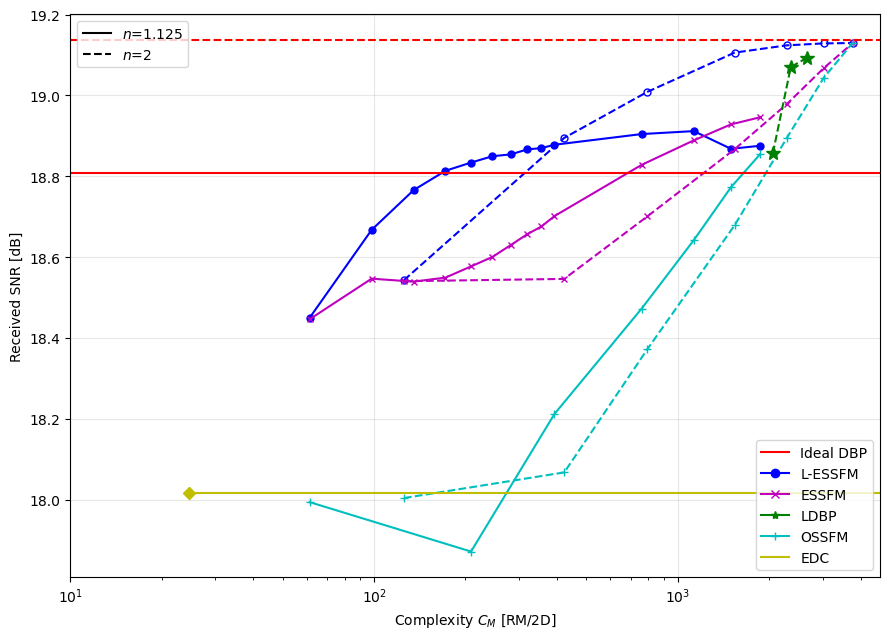

In [7]:
C = {'lessfm':'b','essfm':'m','ossfm':'c','ldbp':'g','edc':'y','ideal':'r'}
fig, ax = plt.subplots(figsize=(9,6.5))
def cx(d, nos): return [eval_compl(n, nos, L_KM, R_GBD) for n in sorted(d)], [d[n] for n in sorted(d)]
# L-ESSFM
x,y = cx(lessfm125,1.125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=5)
if lessfm2: x,y=cx(lessfm2,2.0); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=5)
# ESSFM
x,y = cx(essfm125,1.125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=5)
if essfm2: x,y=cx(essfm2,2.0); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=5)
# OSSFM
x,y = cx(ossfm125,1.125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=6)
x,y = cx(ossfm2,2.0); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=6)
# LDBP (n=2)
if ldbp: ax.plot([c for c,_ in ldbp],[s for _,s in ldbp],color=C['ldbp'],ls='--',marker='*',ms=10)
# Ideal + EDC
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.set_xscale('log'); ax.set_xlim(1e1, ax.get_xlim()[1])
x0 = eval_compl(0,1.125,L_KM,R_GBD)
ax.plot([x0, ax.get_xlim()[1]],[edc,edc],color=C['edc'],ls='-'); ax.plot([x0],[edc],color=C['edc'],marker='D',ms=6)
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$=1.125'),Line2D([0],[0],color='k',ls='--',label='$n$=2')]
l1=ax.legend(handles=meth,loc='lower right',fontsize=10); ax.add_artist(l1); ax.legend(handles=sty,loc='upper left',fontsize=10)
ax.set_xlabel('Complexity $C_M$ [RM/2D]'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig1b.png',dpi=110); plt.show()
